## Fig 3: Lineplots ##

Lineplots were created using Supplemental file 6: Cytoskeleton_DIVs_summarystats.csv (for DIVs).

Scripts include plotting by: ProtClass (rainbow) or Genes selection (Flare).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

In [3]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV2_3,DCX_DIV2_1,DCX_DIV2_2,DCX_DIV3_2,DCX_DIV3_3,DCX_DIV3_1,DCX_DIV4_2,DCX_DIV4_3,DCX_DIV4_1,DCX_DIV5_3,...,Standard deviation DCX_DIV5,Valid values,Valid values DCX_DIV2,Valid values DCX_DIV3,Valid values DCX_DIV4,Valid values DCX_DIV5,Protein.Group,Protein.Ids,Genes,ProtClass
0,15.641337,15.893899,16.109905,15.221670,15.002354,14.744677,17.883825,17.439816,17.181133,15.708421,...,0.160629,13,3,3,3,4,P36873,P36873,PPP1CC,Regulatory
1,16.381990,16.050848,15.980740,15.520720,15.930804,16.057674,18.226049,17.956427,17.418257,17.365852,...,0.388595,13,3,3,3,4,P62136,P62136,PPP1CA,Regulatory
2,14.711737,14.087181,14.018157,12.823722,11.888941,13.194180,16.186760,15.401190,14.859166,15.809014,...,0.539714,13,3,3,3,4,P62140,P62140,PPP1CB,Regulatory
3,15.061861,15.666738,15.550028,13.860582,14.020737,14.406617,15.469521,15.526013,14.988086,15.116920,...,0.382210,17,3,3,3,4,Q9Y266,Q9Y266,NUDC,MAP
4,NaN,11.682411,11.045705,NaN,NaN,NaN,12.544216,13.280929,NaN,13.635707,...,0.537123,8,2,0,2,4,P42684,P42684,ABL2,MAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,12.169324,12.666861,12.682644,12.738861,13.040365,12.882186,13.217134,13.383906,13.770581,12.174314,...,0.585315,13,3,3,3,4,O94901,O94901,SUN1,Nuclear
248,14.947797,14.360161,14.348943,14.683691,15.138052,15.312071,14.351892,14.294865,15.024560,13.765659,...,1.125398,13,3,3,3,4,P02545,P02545,LMNA,Nuclear
249,15.767135,15.247935,15.722480,15.282408,15.981324,15.870441,15.650530,15.718707,15.899567,15.496302,...,0.349046,13,3,3,3,4,P20700,P20700,LMNB1,Nuclear
250,13.677665,14.205702,14.107610,13.787321,13.166529,14.009181,15.780717,15.574499,15.288145,14.935138,...,0.391118,13,3,3,3,4,P50402,P50402,EMD,Nuclear


In [4]:
#Create plots folder

pathmastersheet = Path(askmastersheet)
resultdirectory = str(pathmastersheet.parents[0])+'//Plots'
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
path = newmydir
path

WindowsPath('C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/Curated_Cytoskeleton/Plots')

## Lineplot by ProtClass (DIVs) ##

In [5]:
def plot_profiles_by_class(df, target_class):
    import numpy as np
    import matplotlib.pyplot as plt

    gene_col   = "Genes"
    class_col  = "ProtClass"
    div_cols   = ["Mean DCX_DIV2", "Mean DCX_DIV3", "Mean DCX_DIV4", "Mean DCX_DIV5"]
    div_labels = ["DIV2", "DIV3", "DIV4", "DIV5"]

    # ----------------------------
    # FILTER
    # ----------------------------
    sub = df[df[class_col] == target_class].copy()

    if sub.empty:
        print(f"No data for class: {target_class}")
        return

    # clean
    sub[gene_col] = sub[gene_col].astype(str).str.strip()
    for c in div_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = sub.drop_duplicates(subset=[gene_col], keep="first")

    # ----------------------------
    # PREP DATA
    # ----------------------------
    raw_vals = sub[div_cols].to_numpy(dtype=float)
    nan_mask = np.isnan(raw_vals)

    ymin = 8   # detection threshold
    ymax = 22

    # 👇 KEY CHANGE: push NaNs to detection floor
    vals = np.where(nan_mask, ymin, raw_vals)

    ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1

    x = np.arange(len(div_labels))

    # ----------------------------
    # PLOT
    # ----------------------------
    fig, ax = plt.subplots(figsize=(5, 4))

    for i, row in enumerate(vals):
        gene = sub.iloc[i][gene_col]

        ax.plot(x, row, marker="o", linewidth=1.5, alpha=0.7)

        # mark NaNs (now sitting exactly on the threshold line)
        if nan_mask[i].any():
            ax.scatter(x[nan_mask[i]], row[nan_mask[i]], marker="s", s=30)

    ax.set_xticks(x)
    ax.set_xticklabels(div_labels, fontweight="bold")
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f"{target_class}", fontweight="bold")
    ax.set_ylabel("Mean intensity")

    # 👇 detection floor line now matches NaN placement
    ax.axhline(ymin, linestyle="--", linewidth=1, alpha=0.5)

    sns.despine()
    plt.tight_layout()
    plt.savefig(path / f"LINE_MAPs{date}.svg")
    plt.show()

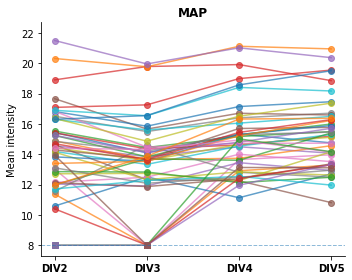

In [6]:
#Plot ONE specific ProtClass

plot_profiles_by_class(data, "MAP")

## Line plot by Gene selection (DIVs) ##

In [7]:
def plot_profiles_by_genes_gradient(df, genes, fill_value=5):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors
    import copy

    gene_col   = "Genes"
    div_cols   = ["Mean DCX_DIV2", "Mean DCX_DIV3", "Mean DCX_DIV4", "Mean DCX_DIV5"]
    div_labels = ["DIV2", "DIV3", "DIV4", "DIV5"]

    # ----------------------------
    # GLOBAL HEATMAP-STYLE COLOR SCALE
    # ----------------------------
    tmp_all = df[[gene_col] + div_cols].copy()
    tmp_all[gene_col] = tmp_all[gene_col].astype(str).str.strip()

    for c in div_cols:
        tmp_all[c] = pd.to_numeric(tmp_all[c], errors="coerce")

    all_vals = tmp_all[div_cols].to_numpy(dtype=float)

    vmin = np.nanpercentile(all_vals, 5)
    vmax = np.nanpercentile(all_vals, 95)

    cmap = copy.copy(cm.get_cmap("flare"))
    cmap.set_bad("#6e6e6e")
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # ----------------------------
    # FILTER SELECTED GENES
    # ----------------------------
    sub = df.copy()
    sub[gene_col] = sub[gene_col].astype(str).str.strip()
    sub = sub[sub[gene_col].isin(genes)]

    if sub.empty:
        print(f"No data found for genes: {genes}")
        return

    sub = sub.drop_duplicates(subset=[gene_col], keep="first")

    ordered_genes = [g for g in genes if g in sub[gene_col].values]
    sub = sub.set_index(gene_col).loc[ordered_genes].reset_index()

    for c in div_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    raw_vals = sub[div_cols].to_numpy(dtype=float)
    x = np.arange(len(div_labels))

    # ----------------------------
    # PLOT
    # ----------------------------
    fig, ax = plt.subplots(figsize=(5, 4))

    for i, raw_row in enumerate(raw_vals):
        gene = sub.iloc[i][gene_col]

        # detect NaNs from the raw data
        nan_positions = np.isnan(raw_row)

        # make a plotting row where NaNs sit at the detection threshold
        row = raw_row.copy()
        row[nan_positions] = 8

        # draw each segment separately, colored by mean intensity of the segment
        for j in range(len(x) - 1):
            seg_x = x[j:j+2]
            seg_y = row[j:j+2]

            raw_pair = raw_row[j:j+2]

# if BOTH points are NaN → grey segment
            if np.all(np.isnan(raw_pair)):
                seg_color = "#6e6e6e"
            else:
                seg_metric = np.nanmean(raw_pair)
                seg_color = cmap(norm(seg_metric))

            ax.plot(
                seg_x,
                seg_y,
                linewidth=1.8,
                alpha=0.95,
                color=seg_color
            )

        # point colors reflect their own intensity; NaNs are grey
        point_colors = []
        for val in raw_row:
            if np.isnan(val):
                point_colors.append("#6e6e6e")
            else:
                point_colors.append(cmap(norm(val)))

        ax.scatter(x, row, s=28,c=point_colors, zorder=3)

        # overlay NaN squares at detection threshold
        if nan_positions.any():
            ax.scatter(
                x[nan_positions],
                row[nan_positions],
                marker="s",
                s=40,
                color="#6e6e6e",
                zorder=4
            )

        # label at end using final-point color
        last_raw = raw_row[-1]
        label_color = "#6e6e6e" if np.isnan(last_raw) else cmap(norm(last_raw))

        ax.text(
            x[-1] + 0.05,
            row[-1],
            gene,
            fontsize=8,
            va="center",
            color=label_color
        )

    ax.set_xticks(x)
    ax.set_xticklabels(div_labels, fontweight="bold")

    ymin = 8
    ymax = 22
    ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_xlim(-0.2, len(x) - 1 + 0.8)

    ax.set_title("WT-enriched (vs R178L)", fontweight="bold")
    ax.set_ylabel("Mean intensity")

    ax.axhline(8, linestyle="--", linewidth=1, alpha=0.5, color="#6e6e6e")

    sns.despine()

    plt.tight_layout()
    plt.savefig(path / f"LINE_GeneSet_enriched{date}.svg")
    plt.show()

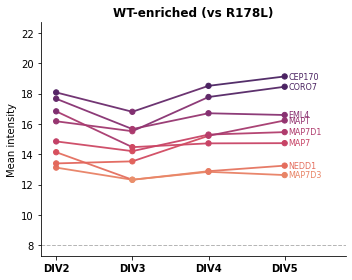

In [8]:
genes_to_plot = ["CORO7", "CEP170","NEDD1", "MAP7D1", "MAP7D3","EML4","MAP7","MAPT"
                
                ]
plot_profiles_by_genes_gradient(data, genes_to_plot, fill_value=5)